# Sleep Stage Sample Audit
This notebook loads a 500,000-row sample, creates an audited subset, checks class balance, reviews missingness, inspects feature correlation, and exports a cleaned audit slice.
The markdown cells explain what each code cell does and how to interpret the main outputs.

## 1. Load Dependencies and the Sample
This cell imports the libraries used throughout the audit and loads the first 500,000 rows from the Hugging Face dataset.
If this cell fails, the problem is usually a missing package or a dataset access issue.

In [ ]:
from datasets import load_dataset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# Load a fixed-size sample for audit work.
ds = load_dataset("abmallick/heart-breath-sleep-stage-dataset", split="train[:500000]")

## 2. Convert to a Pandas DataFrame
This cell materializes the sampled dataset as a DataFrame and prints its size so you know what is being audited.

In [ ]:
df_sample = ds.to_pandas()

print(f"Loaded sample rows: {len(df_sample):,}")
print(f"Loaded sample columns: {df_sample.shape[1]}")

Loaded sample rows: 500,000
Loaded sample columns: 16


## 3. Baseline Class Counts in the Raw Sample
This cell gives a quick baseline count of the raw 500,000-row sample before any split is created.
Use it as a reference point when you compare the audited subset later.

In [ ]:
print("Raw sample sleep stage counts:")
print(df_sample['sleep_stage'].value_counts().sort_index())

Raw sample sleep stage counts:
sleep_stage
0    154414
1     23423
2    199925
3     55187
5     67043
9         8
Name: count, dtype: int64


## 4. Create the Audited Slice
This cell creates `df_audit`, a reproducible 40% stratified subset of the sample.
Because the split is stratified on `sleep_stage`, the class proportions in `df_audit` should closely match the raw sample.

In [ ]:
_, df_audit = train_test_split(
    df_sample,
    test_size=0.4,
    stratify=df_sample['sleep_stage'],
    random_state=42
)

print(f"Audit slice rows: {len(df_audit):,}")
print(f"Audit slice columns: {df_audit.shape[1]}")

Audit slice rows: 200,000
Audit slice columns: 16


## 5. Audit Class Distribution
This cell prints the normalized class distribution for the audited slice.
If the proportions look very different from the raw sample, the split was not representative.

In [ ]:
audit_distribution = df_audit['sleep_stage'].value_counts(normalize=True).sort_index()

print("Audit slice class distribution:")
print(audit_distribution)

Audit slice class distribution:
sleep_stage
0    0.308830
1    0.046845
2    0.399850
3    0.110375
5    0.134085
9    0.000015
Name: proportion, dtype: float64


## 6. Class Imbalance Bar Chart
This cell visualizes the class percentages for `df_audit` and flags any class below the imbalance threshold.
Interpretation: classes below 10% are minority classes and are candidates to flag for later oversampling.

Audit slice class percentages (%):
sleep_stage
2    39.98
0    30.88
5    13.41
3    11.04
1     4.68
9     0.00
Name: proportion, dtype: float64


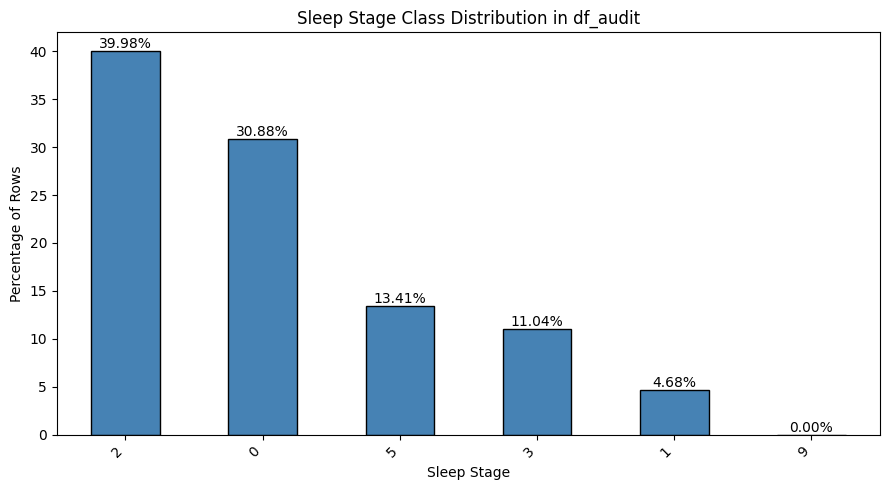

Flag for Sampling Engineer: consider oversampling these classes:
- 1: 4.68%
- 9: 0.00%


In [ ]:
# Compute percentages for the audited slice.
class_pct = (
    df_audit['sleep_stage']
    .value_counts(normalize=True)
    .sort_values(ascending=False)
    .mul(100)
    .round(2)
)

print("Audit slice class percentages (%):")
print(class_pct)

# Plot the class distribution so imbalance is easy to spot.
ax = class_pct.plot(kind='bar', figsize=(9, 5), color='steelblue', edgecolor='black')
ax.set_title('Sleep Stage Class Distribution in df_audit')
ax.set_xlabel('Sleep Stage')
ax.set_ylabel('Percentage of Rows')
ax.bar_label(ax.containers[0], fmt='%.2f%%')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Flag minority classes for the sampling handoff.
imbalance_threshold = 10.0
minority_classes = class_pct[class_pct < imbalance_threshold]

if minority_classes.empty:
    print(f'No class is below {imbalance_threshold:.0f}% of the audit slice.')
else:
    print('Flag for Sampling Engineer: consider oversampling these classes:')
    for stage, pct in minority_classes.items():
        print(f'- {stage}: {pct:.2f}%')

## 7. Missing-Value Pattern Check
This cell summarizes missing-value percentages and plots a heatmap of null positions in `df_audit`.
Interpretation: isolated gaps suggest sporadic missingness, while large vertical bands suggest a whole feature is systematically missing.

Top columns by missing-value percentage:
No missing values found in df_audit.


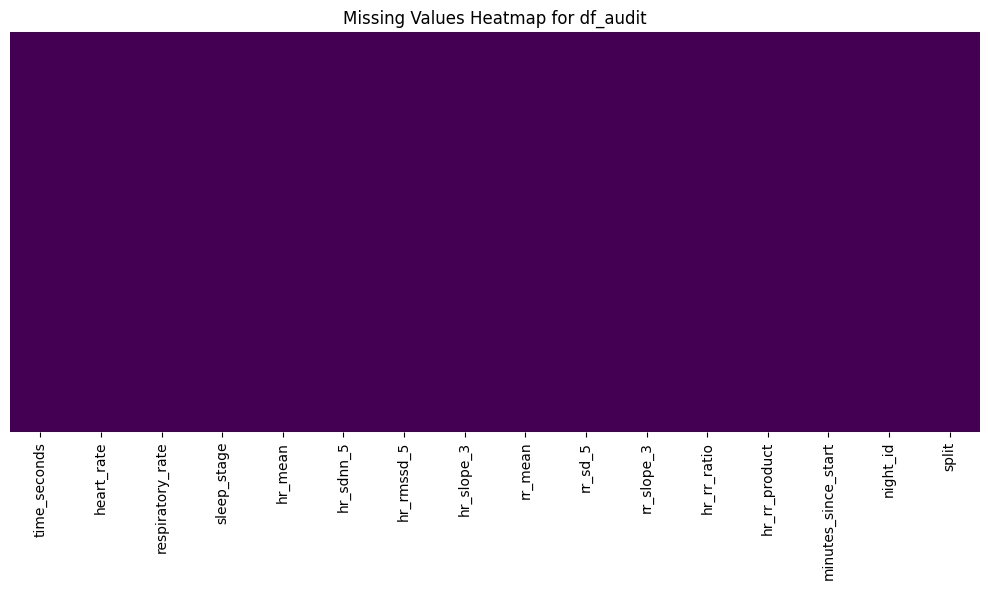

In [ ]:
# Summarize which columns have the most missing values.
missing_pct = df_audit.isnull().mean().sort_values(ascending=False)
missing_pct = (missing_pct[missing_pct > 0] * 100).round(2)

print("Top columns by missing-value percentage:")
if missing_pct.empty:
    print('No missing values found in df_audit.')
else:
    print(missing_pct.head(10))

# Visualize where missing values appear across rows and columns.
plt.figure(figsize=(10, 6))
sns.heatmap(df_audit.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap for df_audit')
plt.tight_layout()
plt.show()

## 8. Feature Correlation Check
This cell checks whether `hr_sdnn_5` and `hr_rmssd_5` move together, then scans all numeric features for highly correlated pairs.
Interpretation: correlations near 1.00 or -1.00 indicate redundant information. Exact duplicates or simple unit conversions should usually be reduced to one column.

Correlation between hr_sdnn_5 and hr_rmssd_5: 0.9500
Recommendation: keep both for now; they are not redundant at the 0.99 threshold.


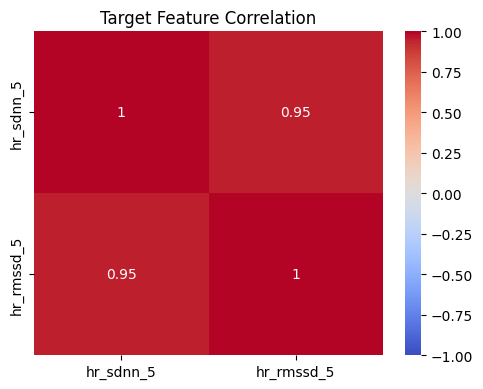

Highly correlated feature pairs to review:
- time_seconds vs minutes_since_start: 1.0000
- heart_rate vs hr_mean: 1.0000
- respiratory_rate vs rr_mean: 1.0000
Recommended columns to drop after correlation review:
['heart_rate', 'respiratory_rate', 'time_seconds']


In [ ]:
# Restrict the correlation check to numeric features.
numeric_df = df_audit.select_dtypes(include='number')
corr_matrix = numeric_df.corr()

target_features = ['hr_sdnn_5', 'hr_rmssd_5']
missing_targets = [feature for feature in target_features if feature not in corr_matrix.columns]

if missing_targets:
    print('Missing target features for this check:', missing_targets)
else:
    pair_corr = corr_matrix.loc['hr_sdnn_5', 'hr_rmssd_5']
    print(f"Correlation between hr_sdnn_5 and hr_rmssd_5: {pair_corr:.4f}")

    if abs(pair_corr) >= 0.99:
        print('Recommendation: drop one of these features because they are effectively redundant.')
    else:
        print('Recommendation: keep both for now; they are not redundant at the 0.99 threshold.')

    pair_heatmap = corr_matrix.loc[target_features, target_features]
    plt.figure(figsize=(5, 4))
    sns.heatmap(pair_heatmap, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title('Target Feature Correlation')
    plt.tight_layout()
    plt.show()

# Scan all numeric features for very high correlation.
threshold = 0.99
high_corr_pairs = []
for left_index, left_feature in enumerate(corr_matrix.columns):
    for right_feature in corr_matrix.columns[left_index + 1:]:
        corr_value = corr_matrix.loc[left_feature, right_feature]
        if abs(corr_value) >= threshold:
            high_corr_pairs.append((left_feature, right_feature, corr_value))

if high_corr_pairs:
    print('Highly correlated feature pairs to review:')
    for left_feature, right_feature, corr_value in sorted(high_corr_pairs, key=lambda item: abs(item[2]), reverse=True):
        print(f"- {left_feature} vs {right_feature}: {corr_value:.4f}")
else:
    print(f'No feature pairs met the |correlation| >= {threshold:.2f} threshold.')

# Confirm which pairs are true duplicates or unit conversions.
recommended_drop_columns = []
if {'heart_rate', 'hr_mean'}.issubset(df_audit.columns) and df_audit['heart_rate'].equals(df_audit['hr_mean']):
    recommended_drop_columns.append('heart_rate')

if {'respiratory_rate', 'rr_mean'}.issubset(df_audit.columns) and df_audit['respiratory_rate'].equals(df_audit['rr_mean']):
    recommended_drop_columns.append('respiratory_rate')

if {'time_seconds', 'minutes_since_start'}.issubset(df_audit.columns):
    is_time_conversion = ((df_audit['time_seconds'] - df_audit['minutes_since_start'] * 60).abs() < 1e-9).all()
    if is_time_conversion:
        recommended_drop_columns.append('time_seconds')

print('Recommended columns to drop after correlation review:')
print(recommended_drop_columns if recommended_drop_columns else 'No drop recommendation from this check.')

## 9. Build the Cleaned Audit Export
This final cell applies the audit decisions to the full 500,000-row sample: it removes stage `9`, drops redundant columns identified during the audit, maps sleep-stage labels, and exports a cleaned file.
Interpretation: the audit is performed on `df_audit`, but the exported CSV is built from the full sampled dataset so the handoff uses the larger cleaned sample.

In [ ]:
# Apply the audit decisions to the full sampled dataset, not just the audit slice.
df_export_clean = df_sample[df_sample['sleep_stage'] != 9].copy()
columns_to_drop = [column for column in ['time_seconds', 'heart_rate', 'respiratory_rate'] if column in df_export_clean.columns]
df_export_clean = df_export_clean.drop(columns=columns_to_drop)

# Add readable stage labels for downstream review.
stage_mapping = {
    0: 'Wake',
    1: 'N1_Light',
    2: 'N2_Light',
    3: 'N3_Deep',
    5: 'REM',
}

df_export_clean['stage_name'] = df_export_clean['sleep_stage'].map(stage_mapping)

print("Cleaned full-sample distribution:")
print(df_export_clean['stage_name'].value_counts(dropna=False))
print("\nPreview of cleaned full sample:")
print(df_export_clean.head())

EXPORT_PATH = 'sleep_stage_sample_cleaned.csv'
df_export_clean.to_csv(EXPORT_PATH, index=False)

print(f"\nExported cleaned full sample to {EXPORT_PATH}")
print(len(df_export_clean), "rows and", df_export_clean.shape[1], "columns in the exported file.")

Cleaned full-sample distribution:
stage_name
N2_Light    199925
Wake        154414
REM          67043
N3_Deep      55187
N1_Light     23423
Name: count, dtype: int64

Preview of cleaned full sample:
   sleep_stage  hr_mean  hr_sdnn_5  hr_rmssd_5  hr_slope_3  rr_mean  rr_sd_5  \
0            5    87.42       0.93        1.31        1.31     7.23     1.45   
1            5    88.73       0.93        1.31        1.31     9.28     1.45   
2            5    90.29       1.44        1.44        1.44    21.51     7.72   
3            5    86.83       1.54        2.32       -0.20    27.59     9.77   
4            5    85.86       1.73        2.07       -0.96    27.07     9.71   

   rr_slope_3  hr_rr_ratio  hr_rr_product  minutes_since_start  night_id  \
0        2.05        12.09         632.05                  0.0         1   
1        2.05         9.56         823.41                  0.5         1   
2        7.14         4.20        1942.14                  1.0         1   
3        6.79   